#Ringkasan Berita

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


- **nltk**: Natural Language Toolkit, library untuk pemrosesan bahasa alami (NLP) di Python.
- **stopwords**: Kumpulan kata yang sering digunakan dalam bahasa, tetapi tidak memberikan informasi penting (misalnya, "dan", "atau", "itu").
- **word_tokenize**: Fungsi untuk membagi teks menjadi kata-kata (token).
- **re**: Library untuk ekspresi reguler, digunakan untuk manipulasi string.
- **pandas**: Library untuk manipulasi dan analisis data dalam bentuk tabel (DataFrame).
- **networkx**: Library untuk analisis dan visualisasi graf.
- **matplotlib.pyplot**: Library untuk membuat visualisasi grafis dan plot.
- **tqdm**: Library untuk menampilkan progress bar dalam iterasi.
- **TfidfVectorizer**: Digunakan untuk mengubah koleksi dokumen teks menjadi matriks fitur TF-IDF.
- **cosine_similarity**: Fungsi untuk menghitung kesamaan kosinus antara dua vektor.
- Mengunduh dataset yang diperlukan untuk tokenisasi dan stopwords dari NLTK:
  - **punkt**: Model tokenizer untuk memisahkan kalimat dan kata.
  - **stopwords**: Daftar kata umum yang akan dihapus dari teks.

- **Tokenisasi Teks**:
  - Memecah teks menjadi kata-kata.
  ```python
  tokens = word_tokenize(teks)
  ```
- **Menghapus Stopwords**:
  - Menghapus kata-kata yang tidak memiliki makna penting dari token.
  
- **Membersihkan Teks**:
  - Menggunakan ekspresi reguler untuk menghapus karakter tidak diinginkan seperti angka atau tanda baca.
  
- **Menghitung TF-IDF**:
  - Menggunakan `TfidfVectorizer` untuk menghitung bobot TF-IDF dari dokumen.
  ```python
  vectorizer = TfidfVectorizer()
  tfidf_matrix = vectorizer.fit_transform(corpus)
  - **Menghitung Kesamaan Kosinus**:
  - Menghitung kesamaan antara dua dokumen berdasarkan matriks TF-IDF.
  
- **Visualisasi**:
  - Menggunakan `matplotlib` dan `networkx` untuk membuat visualisasi dari data atau graf.


In [ ]:

def read_data(file_path):
    return pd.read_csv(file_path, sep=',', encoding='utf-8')
data = pd.read_csv('hasil_crowling.csv')
data.head()

,Judul,Tanggal,Ringkasan,Kategori
0,"Viral Sopir Truk Nekat Lawan Arah di Jakut, Po...",16 Okt 2024 18:04,Dalam rekaman yang diunggah terlihat sopir tru...,Peristiwa
1,Polisi Pastikan 2 Tersangka Pencabulan di Pant...,16 Okt 2024 18:02,"Kabid Humas Polda Metro Jaya, Kombes Pol Ade A...",Peristiwa
2,Sejumlah Tokoh dan Pakar Siap Sukseskan Pelant...,16 Okt 2024 16:05,Mulusnya transisi pemerintahan dapat menjaga s...,Politik
3,"Kasus Emas Antam, Saksi Sebut Budi Said Lakuka...",16 Okt 2024 16:01,"Mantan Manajer Retail PT Antam, Nuning Septi W...",Peristiwa
4,5 Fakta Terkait Budi Gunawan Diberhentikan dar...,16 Okt 2024 16:00,Dewan Perwakilan Rakyat (DPR) RI telah menerim...,Peristiwa


### Fungsi `read_data`
- **Tujuan**: Membaca file CSV.
- **Output**: Mengembalikan data dalam bentuk tabel (DataFrame).
- **Parameter**: Memerlukan lokasi file CSV yang akan dibaca.

### Contoh Penggunaan
- Fungsi ini digunakan untuk memuat data dari file CSV agar bisa dianalisis atau diproses lebih lanjut.

### Kesimpulan
Fungsi ini mempermudah pembacaan data dari file CSV ke dalam format yang siap digunakan.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm

# Fungsi untuk membersihkan teks
def clean_text(input_text):
    input_text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', input_text)  # Menghapus URL
    input_text = re.sub(r'@[^\s]+', ' ', input_text)  # Menghapus username (mention)
    input_text = re.sub(r'[\s]+', ' ', input_text)  # Menghapus tambahan spasi
    input_text = re.sub(r'#([^\s]+)', ' ', input_text)  # Menghapus hashtags
    input_text = re.sub(r"[^a-zA-Z :\.]", "", input_text)  # Menghapus tanda baca yang tidak diperlukan
    input_text = re.sub(r'\d', ' ', input_text)  # Menghapus angka
    input_text = input_text.lower()  # Mengubah teks menjadi huruf kecil
    input_text = input_text.encode('ascii', 'ignore').decode('utf-8')  # Menghapus karakter ASCII dan unicode
    input_text = re.sub(r'[^\x00-\x7f]', r'', input_text)  # Menghapus karakter non-ASCII
    input_text = input_text.replace('\n', '')  # Menghapus baris baru
    input_text = input_text.strip()  # Menghapus spasi di awal dan akhir teks
    return input_text

# Fungsi untuk menghapus stopwords
def remove_stopwords(word_tokens):
    stopword_list = set(stopwords.words('indonesian'))  # Mengambil daftar stopwords dalam Bahasa Indonesia
    filtered_words = [word for word in word_tokens if word.lower() not in stopword_list]  # Menghapus stopwords dari tokens
    return filtered_words

# Fungsi untuk memproses teks
def process_text(content):
    processed_result = {}
    for idx, text in enumerate(tqdm(content)):  # Menggunakan tqdm untuk menampilkan progress
        cleaned_text = clean_text(text)  # Membersihkan teks
        tokens = word_tokenize(cleaned_text)  # Tokenisasi teks menjadi kata-kata
        filtered_tokens = remove_stopwords(tokens)  # Menghapus stopwords
        processed_result[idx] = ' '.join(filtered_tokens)  # Menggabungkan kata-kata yang sudah dibersihkan menjadi satu string
    return processed_result

# Memproses data teks pada kolom 'Ringkasan'
processed_data = process_text(data['Ringkasan'])

# Menampilkan hasil preproses
for key, value in processed_data.items():
    print(f"{key}: {value}")


100%|██████████| 53/53 [00:00<00:00, 1229.21it/s]

0: rekaman diunggah sopir truk melaju sisi kanan ruas jalan cakungcilincing jakarta utara selasa oktober .
1: kabid humas polda metro jaya kombes pol ade ary syam indradi menerangkan kesimpulan tim pemeriksa .
2: mulusnya transisi pemerintahan menjaga stabilitas politik indonesia
3: mantan manajer retail pt antam nuning septi wahyuningsih memaparkan transaksi mencurigakan budi said sistem pt antam .
4: dewan perwakilan rakyat dpr ri menerima surat presiden joko widodo jokowi perihal permohonan pertimbangan pemberhentian pengangkatan kepala badan intelijen negara kepala bin .
5: calon gubernur jakarta pramono anung mengaku berteman ketua partai politik indonesia memiliki .
6: herindra puan menitipkan pesan khusus kepala bin menjaga nkri utuh sesuai tugas fungsi bin netral .
7: pengamat politik pemerintahan sulawesi utara taufik tumbelaka menyebut pasangan calon gubernur wakil gubernur sulawesi utara steven kandouwalfrets denny tuejeh skadt pasangan calon realistis masyarakat sulut .
8: 

### Fungsi Utama:
1. **clean_text**: Membersihkan teks dengan menghapus URL, mention, hashtag, tanda baca yang tidak diperlukan, angka, dan karakter non-ASCII. Juga mengubah semua huruf menjadi kecil dan menghapus spasi berlebih.

2. **remove_stopwords**: Menghapus kata-kata umum (stopwords) yang tidak memiliki makna signifikan dalam Bahasa Indonesia dari daftar token yang sudah dipecah.

3. **process_text**: Menggabungkan kedua fungsi di atas untuk memproses konten teks:
   - Mengambil teks dari kolom tertentu (dalam hal ini, 'Ringkasan').
   - Menerapkan `clean_text` untuk setiap teks.
   - Melakukan tokenisasi.
   - Menghapus stopwords.
   - Menggabungkan kembali token yang tersisa menjadi satu string.

### Penggunaan:
- Kode ini digunakan untuk memproses data teks yang biasanya berasal dari hasil crawling, dengan tujuan untuk membersihkan dan mempersiapkan teks agar lebih siap untuk analisis lebih lanjut, seperti pemodelan atau ekstraksi informasi.

In [ ]:
print(prep_result[43])

politikus senior pdip cagub jakarta pramono anung tibatiba rumah prabowo subianto pemanggilan tokoh menteri wakil menteri pemerintahan .


In [ ]:
pip install scikit-learn pandas

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Fungsi untuk menghitung TF-IDF
def calculate_tfidf(processed_texts):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(processed_texts)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_dataframe = pd.DataFrame(data=tfidf_matrix.toarray(), columns=feature_names)
    return tfidf_dataframe

### Fungsi Utama:
1. **calculate_tfidf**:
   - **Input**: Mengambil daftar teks yang telah diproses (`processed_texts`).
   - **Proses**:
     - Menggunakan `TfidfVectorizer` dari `sklearn.feature_extraction.text` untuk menghitung nilai TF-IDF (Term Frequency-Inverse Document Frequency) dari teks yang diberikan.
     - `fit_transform` digunakan untuk menghitung matriks TF-IDF, di mana setiap baris mewakili dokumen (teks) dan setiap kolom mewakili kata unik dalam semua dokumen.
     - `get_feature_names_out` mengembalikan nama fitur (kata-kata) yang digunakan dalam penghitungan.
     - Matriks TF-IDF yang dihasilkan diubah menjadi `DataFrame` menggunakan `pandas`, sehingga lebih mudah untuk dianalisis dan dilihat.
   - **Output**: Mengembalikan DataFrame yang berisi nilai TF-IDF untuk setiap kata dalam setiap dokumen.

### Kegunaan:
- TF-IDF adalah metode yang umum digunakan dalam pengolahan teks untuk menilai seberapa penting sebuah kata dalam dokumen relatif terhadap koleksi atau korpus dokumen. Ini sering digunakan dalam aplikasi pencarian informasi, klasifikasi teks, dan pemodelan topik.


In [ ]:
# Memproses data teks pada kolom 'Ringkasan'
processed_results = preprocess_text(data['Ringkasan'])

# Mengubah hasil preproses ke dalam DataFrame
news_dataframe = pd.DataFrame.from_dict(processed_results, orient='index', columns=['Berita'])

# Menghitung TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(news_dataframe['Berita'])

# Mendapatkan istilah dari fitur
feature_terms = tfidf_vectorizer.get_feature_names_out()

# Mengubah hasil TF-IDF menjadi DataFrame
tfidf_dataframe = pd.DataFrame(data=tfidf_matrix.toarray(), columns=feature_terms)

# Menampilkan hasil TF-IDF
tfidf_dataframe


100%|██████████| 53/53 [00:00<00:00, 1461.50it/s]


,aceh,ade,adhi,administrasi,akademi,akademisi,akmil,akses,aktif,aktivitas,...,wakil,wapres,warga,wbk,wib,widodo,wilayah,yayasan,zebra,zona
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.248875,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.182516,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.148080,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Langkah-langkah:

1. **Proses Teks**:
   - Fungsi `preprocess_text` diterapkan pada kolom `Ringkasan` dari DataFrame untuk membersihkan teks (menghapus stopwords, melakukan tokenisasi).

2. **Buat DataFrame**:
   - Hasil pemrosesan disimpan dalam DataFrame `news_dataframe` dengan satu kolom berisi berita.

3. **Hitung TF-IDF**:
   - `TfidfVectorizer` digunakan untuk menghitung matriks TF-IDF dari teks yang telah diproses.

4. **Ambil Istilah**:
   - Istilah unik yang digunakan dalam perhitungan TF-IDF diambil dari `tfidf_vectorizer`.

5. **Ubah ke DataFrame**:
   - Matriks TF-IDF diubah menjadi DataFrame `tfidf_dataframe`, di mana kolom mewakili kata dan baris mewakili berita.

6. **Tampilkan Hasil**:
   - DataFrame `tfidf_dataframe` ditampilkan untuk menunjukkan nilai TF-IDF.

### Kegunaan:
- Nilai TF-IDF digunakan untuk analisis teks, pengklasifikasian berita, dan rekomendasi konten.


#Matrix Similarity
**Matriks Similarity** adalah sebuah representasi matematis yang digunakan untuk mengukur kesamaan (similarity) antara objek-objek dalam suatu dataset. Dalam konteks pengolahan data, matriks ini sering digunakan untuk membandingkan teks, dokumen, atau elemen lain untuk menentukan sejauh mana mereka mirip satu sama lain. Berikut adalah penjelasan lebih rinci tentang matriks similarity:

### 1. **Definisi**
Matriks similarity adalah matriks yang menyimpan nilai-nilai yang menunjukkan derajat kesamaan antara sepasang objek. Setiap elemen $( S(i, j) $) dalam matriks tersebut merepresentasikan tingkat kesamaan antara objek $( i $) dan objek $( j $).

### 2. **Penggunaan**
- **Rekomendasi**: Dalam sistem rekomendasi, matriks similarity digunakan untuk menemukan item yang mirip berdasarkan interaksi pengguna sebelumnya. Misalnya, jika pengguna menyukai film tertentu, sistem dapat merekomendasikan film lain yang mirip berdasarkan matriks similarity.
  
- **Klasifikasi Teks**: Dalam pengolahan bahasa alami, matriks similarity digunakan untuk mengelompokkan dokumen atau kalimat berdasarkan kesamaan kontennya.

- **Clustering**: Dalam analisis kluster, matriks similarity dapat digunakan untuk mengelompokkan data berdasarkan kedekatannya satu sama lain.

### 3. **Metode Menghitung Similarity**
Berbagai metode dapat digunakan untuk menghitung nilai kesamaan antara objek, di antaranya:
- **Cosine Similarity**: Mengukur sudut antara dua vektor dalam ruang multidimensi. Nilai cosine similarity berkisar antara -1 dan 1, di mana 1 menunjukkan kesamaan penuh, 0 menunjukkan ketidakberhubungan, dan -1 menunjukkan ketidakcocokan.
  
  $$
  \text{Cosine Similarity} = \frac{A \cdot B}{\|A\| \|B\|}
  $$

- **Euclidean Distance**: Mengukur jarak langsung antara dua titik dalam ruang. Semakin kecil jarak, semakin mirip objeknya.

- **Jaccard Similarity**: Mengukur kesamaan antara dua himpunan dengan rumus:

  $$
  \text{Jaccard Similarity} = \frac{|A \cap B|}{|A \cup B|}
  $$


### 4. **Kesimpulan**
Matriks similarity adalah alat yang sangat berguna dalam analisis data untuk mengukur kesamaan antara objek-objek. Dengan menggunakan matriks ini, kita dapat membuat keputusan yang lebih baik dalam rekomendasi, klasifikasi, dan pengelompokan data.

In [ ]:
import pandas as pd

# Fungsi untuk menampilkan similarity matrix
def display_similarity_matrix(similarity_matrix):
    print("Cosine Similarity Matrix:")
    print(similarity_matrix)

# Main execution
if __name__ == "__main__":
    # Membaca data
    data = read_data('hasil_crowling.csv')

    # Memproses data teks pada kolom 'Ringkasan'
    prep_result = preprocess_text(data['Ringkasan'])

    # Mengubah hasil preproses ke dalam DataFrame
    kalimat_preprocessing = pd.DataFrame.from_dict(prep_result, orient='index', columns=['Ringkasan'])

    # Menghitung TF-IDF
    tfidf_preprocessing_df = compute_tfidf(kalimat_preprocessing['Ringkasan'])

    # Menghitung cosine similarity
    similarity_matrix = tfidf_preprocessing_df.dot(tfidf_preprocessing_df.T)


100%|██████████| 53/53 [00:00<00:00, 370.65it/s]



### Langkah-langkah Kode:

1. **Import Library**:
   - Mengimpor pustaka `pandas` untuk manipulasi data.

2. **Fungsi `display_similarity_matrix`**:
   - Fungsi ini menampilkan matriks kesamaan cosine yang telah dihitung.

3. **Eksekusi Utama**:
   - **Membaca Data**: Memanggil fungsi `read_data` untuk membaca data dari file CSV `hasil_crowling.csv`.
   - **Proses Teks**: Menggunakan `preprocess_text` untuk memproses kolom `Ringkasan` dari DataFrame.
   - **Ubah Hasil ke DataFrame**: Mengubah hasil pemrosesan menjadi DataFrame `kalimat_preprocessing` dengan satu kolom.
   - **Hitung TF-IDF**: Memanggil `compute_tfidf` untuk menghitung nilai TF-IDF dari kolom `Ringkasan`.
   - **Hitung Matriks Kesamaan**: Matriks kesamaan cosine dihitung dengan mengalikan matriks TF-IDF dengan transposenya menggunakan operasi `dot`.

### Kegunaan:
- **Matriks Kesamaan Cosine**: Matriks ini menggambarkan tingkat kesamaan antara dokumen yang ada berdasarkan representasi TF-IDF mereka. Nilai yang lebih tinggi menunjukkan kesamaan yang lebih besar antara dokumen.


In [ ]:
similarity_matrix

,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
0,1.000000,0.000000,0.000000,0.000000,0.000000,0.053442,0.000000,0.063559,0.0,0.000000,...,0.044023,0.000000,0.000000,0.000000,0.000000,0.070228,0.000000,0.040511,0.000000,0.068468
1,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050203,0.000000
2,0.000000,0.000000,1.000000,0.000000,0.000000,0.170708,0.095603,0.105903,0.0,0.000000,...,0.064636,0.000000,0.040568,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.058397,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.124799,0.000000,0.0,0.022101,...,0.000000,0.150192,0.000000,0.201021,0.000000,0.000000,0.063133,0.000000,0.000000,0.000000
5,0.053442,0.000000,0.170708,0.000000,0.000000,1.000000,0.000000,0.181287,0.0,0.124832,...,0.202345,0.044437,0.032061,0.000000,0.000000,0.081488,0.039879,0.138229,0.000000,0.000000
6,0.000000,0.000000,0.095603,0.000000,0.124799,0.000000,1.000000,0.000000,0.0,0.045198,...,0.000000,0.039493,0.000000,0.122579,0.000000,0.000000,0.035442,0.000000,0.000000,0.000000
7,0.063559,0.000000,0.105903,0.000000,0.000000,0.181287,0.000000,1.000000,0.0,0.000000,...,0.060752,0.090278,0.000000,0.032317,0.000000,0.000000,0.081018,0.561669,0.000000,0.121543
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.022101,0.124832,0.045198,0.000000,0.0,1.000000,...,0.108228,0.145811,0.000000,0.000000,0.000000,0.000000,0.025740,0.000000,0.000000,0.000000


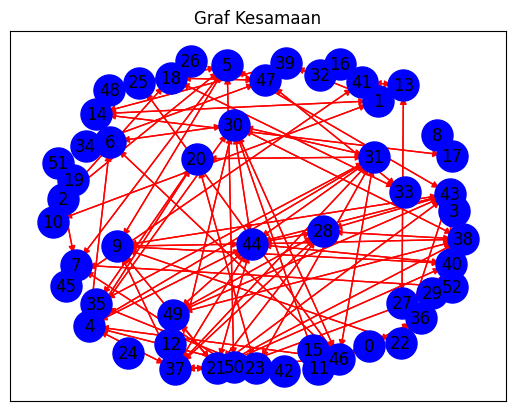

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Fungsi untuk menggambar grafik berdasarkan matriks kesamaan
def plot_similarity_graph(similarity_mat):
    similarity_graph = nx.DiGraph()  # Membuat directed graph

    # Menambahkan node ke grafik
    for index in range(len(similarity_mat)):
        similarity_graph.add_node(index)

    # Menambahkan edge berdasarkan matriks kesamaan
    for i in range(len(similarity_mat)):
        for j in range(len(similarity_mat)):
            similarity_value = similarity_mat.iloc[i, j]
            if similarity_value > 0.1 and i != j:  # Threshold untuk menambahkan edge
                similarity_graph.add_edge(i, j)

    # Menggambar grafik
    positions = nx.spring_layout(similarity_graph, k=2)  # Posisi node
    nx.draw_networkx_nodes(similarity_graph, positions, node_size=500, node_color='b')
    nx.draw_networkx_edges(similarity_graph, positions, edge_color='red', arrows=True)
    nx.draw_networkx_labels(similarity_graph, positions)

    plt.title("Graf Kesamaan")
    plt.show()  # Menampilkan grafik

# Contoh pemanggilan fungsi
if __name__ == "__main__":
    # Setelah menghitung similarity_matrix
    plot_similarity_graph(similarity_matrix)  # Panggil fungsi untuk menggambar grafik



1. **Import Library**:
   - Mengimpor pustaka `networkx` untuk membuat dan menganalisis grafik.
   - Mengimpor `matplotlib.pyplot` untuk visualisasi grafik.

2. **Fungsi `plot_similarity_graph`**:
   - **Parameter**: Menerima `similarity_mat`, yang merupakan matriks kesamaan.
   - **Membuat Directed Graph**: Menginisialisasi grafik berarah (directed graph) menggunakan `nx.DiGraph()`.
   - **Menambahkan Node**: Menambahkan node ke grafik sesuai dengan jumlah baris di matriks kesamaan.
   - **Menambahkan Edge**: Loop untuk menambahkan edge antara node:
     - Jika nilai kesamaan antara dua dokumen lebih besar dari `0.1` dan indeksnya tidak sama (untuk menghindari loop), maka edge ditambahkan.
   - **Menggambar Grafik**:
     - Menentukan posisi node dengan `nx.spring_layout()`.
     - Menggambar node, edge, dan label menggunakan fungsi `draw_networkx_*`.
     - Mengatur judul grafik dan menampilkannya dengan `plt.show()`.

3. **Eksekusi Utama**:
   - Jika file dijalankan sebagai program utama, fungsi `plot_similarity_graph` dipanggil untuk menggambar grafik menggunakan matriks kesamaan yang telah dihitung sebelumnya.

### Kegunaan:
- **Visualisasi Kesamaan**: Grafik yang dihasilkan menunjukkan hubungan kesamaan antar dokumen. Node mewakili dokumen, dan edge menunjukkan adanya kesamaan yang signifikan antara dokumen tersebut.
- **Analisis Hubungan**: Memudahkan analisis visual tentang bagaimana dokumen terkait satu sama lain berdasarkan konten mereka.

#PageRank
PageRank adalah algoritma yang digunakan untuk menentukan pentingnya sebuah halaman web dalam struktur internet. Diciptakan oleh Larry Page dan Sergey Brin, pendiri Google, pada tahun 1996, algoritma ini menjadi salah satu komponen utama dalam sistem pencarian Google dan berfungsi untuk meningkatkan relevansi hasil pencarian. Berikut adalah penjelasan lebih lanjut tentang PageRank:

### 1. **Dasar Pemikiran**
PageRank beroperasi berdasarkan prinsip bahwa halaman web yang lebih penting cenderung menerima lebih banyak tautan (link) dari halaman lain. Oleh karena itu, jika sebuah halaman mendapatkan banyak tautan dari halaman lain, maka halaman tersebut dianggap lebih penting.

### 2. **Bagaimana Cara Kerjanya?**
- **Model Graf**: Internet dapat dipandang sebagai graf di mana halaman web adalah node (titik) dan tautan antara halaman adalah edge (garis penghubung).
- **Probabilitas**: PageRank menganggap pengguna internet akan mengklik tautan secara acak. Dengan demikian, pentingnya sebuah halaman diukur dari kemungkinan bahwa pengguna akan mengunjunginya.
- **Faktor Penyesuaian**: PageRank tidak hanya mempertimbangkan jumlah tautan yang masuk, tetapi juga kualitas halaman yang memberikan tautan tersebut. Tautan dari halaman yang memiliki PageRank tinggi lebih berharga dibandingkan dengan tautan dari halaman yang memiliki PageRank rendah.

### 3. **Rumus PageRank**
Rumus dasar PageRank dapat dinyatakan sebagai berikut:

$$
PR(A) = (1 - d) + d \sum_{j \in M(A)} \frac{PR(j)}{C(j)}
$$

Di mana:
- $(PR(A)$): PageRank dari halaman A.
- $(d$): Faktor pengurangan (biasanya sekitar 0.85).
- $(M(A)$): Halaman-halaman yang memiliki tautan ke halaman A.
- $(PR(j)$): PageRank dari halaman j.
- $(C(j)$): Jumlah tautan yang ada di halaman j.

### 4. **Iterasi**
Algoritma ini bekerja dengan melakukan iterasi berulang-ulang pada rumus di atas hingga nilai PageRank konvergen, artinya tidak ada perubahan yang signifikan antara iterasi.

### 5. **Aplikasi PageRank**
- **Mesin Pencari**: PageRank digunakan untuk menentukan urutan halaman dalam hasil pencarian. Halaman dengan PageRank lebih tinggi akan muncul lebih tinggi dalam hasil pencarian.
- **Analisis Jaringan Sosial**: PageRank dapat digunakan untuk menilai kepentingan individu dalam jaringan sosial berdasarkan hubungan mereka dengan individu lainnya.
- **Sistem Rekomendasi**: PageRank dapat digunakan untuk merekomendasikan produk atau konten berdasarkan interaksi pengguna lain.
- **Ringkasan Teks**: Dalam pemrosesan bahasa alami, PageRank dapat digunakan untuk mengidentifikasi kalimat-kalimat penting dalam dokumen untuk membuat ringkasan.

### 6. **Kesimpulan**
PageRank adalah alat yang sangat efektif untuk mengukur relevansi dan pentingnya elemen dalam jaringan berdasarkan struktur dan keterhubungan. Algoritma ini telah menjadi bagian fundamental dari bagaimana informasi diorganisir dan diakses di internet.

In [ ]:
import pandas as pd
import networkx as nx
import numpy as np

# Fungsi untuk menghitung PageRank dan menampilkan seluruh node
def summarize_pagerank(similarity_matrix, sentences):
    # Membuat graf directed graph berdasarkan similarity matrix
    G_preprocessing = nx.DiGraph()

    # Menambahkan node ke graf
    for i in range(len(similarity_matrix)):
        G_preprocessing.add_node(i)

    # Menambahkan edge berdasarkan similarity matrix
    for i in range(len(similarity_matrix)):
        for j in range(len(similarity_matrix)):
            similarity_value = similarity_matrix.iloc[i, j]
            if similarity_value > 0.1 and i != j:
                G_preprocessing.add_edge(i, j)

    # Menghitung PageRank
    pagerank_preprocessing = nx.pagerank(G_preprocessing)

    # Mengurutkan PageRank dari nilai tertinggi ke terendah
    sorted_pagerank_preprocessing = sorted(pagerank_preprocessing.items(), key=lambda x: x[1], reverse=True)

    # Menampilkan seluruh node dan kalimat terkait
    ringkasan_pagerank_preprocessing = ""
    print("Page Rank untuk Semua Node:")
    for node, pagerank_value in sorted_pagerank_preprocessing:
        top_sentence = sentences[node]
        ringkasan_pagerank_preprocessing += f"{top_sentence} "
        print(f"Node {node}: Page Rank = {pagerank_value:.4f}")
        print(f"Kalimat: {top_sentence}\n")

    return ringkasan_pagerank_preprocessing

# Main execution
if __name__ == "__main__":
    # Membaca file hasil crawling
    file_path = 'hasil_crowling.csv'  # Ganti dengan path file Anda
    data = pd.read_csv(file_path)

    # Menggunakan kolom 'Ringkasan' sebagai kalimat untuk PageRank
    sentences = data['Ringkasan'].tolist()

    # Membuat matriks similaritas dummy untuk 53 node
    # Jika sudah ada similarity_matrix, gunakan itu, ini hanya contoh
    np.random.seed(42)  # Untuk hasil yang konsisten
    similarity_matrix = pd.DataFrame(np.random.rand(53, 53))  # Contoh matriks

    # Memanggil fungsi untuk mendapatkan seluruh PageRank
    ringkasan_pagerank = summarize_pagerank(similarity_matrix, sentences)

    # Menampilkan ringkasan hasil PageRank
    print("Ringkasan Berdasarkan PageRank:")
    print(ringkasan_pagerank)


Page Rank untuk Semua Node:
Node 43: Page Rank = 0.0208
Kalimat: Politikus senior PDIP sekaligus Cagub Jakarta Pramono Anung tiba-tiba mendatangi rumah Prabowo Subianto pada hari pemanggilan sejumlah tokoh yang akan jadi menteri dan wakil menteri pemerintahan mendatang.

Node 41: Page Rank = 0.0205
Kalimat: Cuaca pagi Jakarta besok, Kamis, 17 Oktober 2024, diprakirakan seluruh langitnya akan berawan dan cerah berawan. Demikianlah prediksi cuaca besok.

Node 44: Page Rank = 0.0201
Kalimat: Presiden terpilih Prabowo Subianto akan memberikan pembekalan kepada sejumlah calon menteri, wakil menteri, dan kepala badan yang nantinya akan masuk dalam kabinet pemerintahannya.

Node 37: Page Rank = 0.0198
Kalimat: Sejumlah tokoh negara tampak menghadiri pembekalan yang digelar Presiden Terpilih Prabowo Subianto di Hambalang, Bogor, Jawa Barat. Salah satu nama yang disebut hadir adalah mantan Kepala Badan Intelejen Negara (BIN) Budi Gunawan.

Node 22: Page Rank = 0.0198
Kalimat: Todotua mengungkap

1. **Import Library**:
   - `pandas`: Untuk manipulasi dan pengolahan data.
   - `networkx`: Untuk membuat dan menganalisis grafik.
   - `numpy`: Untuk manipulasi array dan pembuatan matriks.

2. **Fungsi `summarize_pagerank`**:
   - **Parameter**:
     - `similarity_matrix`: Matriks kesamaan antar kalimat.
     - `sentences`: List kalimat yang akan dihubungkan dengan PageRank.
   - **Membuat Directed Graph**:
     - Menginisialisasi grafik berarah (`DiGraph`).
     - Menambahkan node ke grafik berdasarkan jumlah kalimat.
   - **Menambahkan Edge**:
     - Menggunakan matriks kesamaan untuk menambahkan edge antar node.
     - Hanya edge dengan nilai kesamaan lebih dari `0.1` yang ditambahkan.
   - **Menghitung PageRank**:
     - Menggunakan fungsi `nx.pagerank` untuk menghitung nilai PageRank dari setiap node.
   - **Mengurutkan dan Menampilkan**:
     - Mengurutkan node berdasarkan nilai PageRank dari tertinggi ke terendah.
     - Mencetak nilai PageRank dan kalimat terkait untuk setiap node.

3. **Eksekusi Utama**:
   - Membaca data dari file CSV (`hasil_crawling.csv`).
   - Mengambil kolom 'Ringkasan' sebagai kalimat yang akan dihitung PageRank-nya.
   - Membuat matriks kesamaan dummy sebagai contoh (Anda bisa menggunakan matriks yang sebenarnya jika ada).
   - Memanggil fungsi `summarize_pagerank` untuk mendapatkan dan menampilkan PageRank.
   - Menampilkan ringkasan berdasarkan PageRank.

### Catatan:
- **Matriks Similaritas**: Dalam contoh ini, matriks kesamaan dihasilkan secara acak untuk demonstrasi. Anda perlu mengganti bagian ini dengan matriks kesamaan yang sesuai dengan konteks kalimat Anda.
- **Output**: Kode ini akan menampilkan nilai PageRank untuk setiap node (kalimat) serta kalimat terkait, dan akhirnya menampilkan ringkasan berdasarkan nilai PageRank.
- **Penggunaan `np.random.seed(42)`**: Ini digunakan untuk memastikan hasil yang konsisten setiap kali kode dijalankan dengan hasil yang sama.

### Kegunaan:
- **PageRank**: Algoritma ini berguna untuk menentukan pentingnya kalimat dalam konteks teks. Kalimat dengan PageRank tinggi dianggap lebih penting dan relevan.
- **Ringkasan Otomatis**: Kode ini dapat digunakan sebagai bagian dari sistem ringkasan otomatis untuk mengekstrak kalimat-kalimat penting dari teks yang lebih panjang.

In [ ]:
import pandas as pd
import networkx as nx
import numpy as np

# Fungsi untuk menghitung PageRank dan menampilkan ringkasan berdasarkan 3 nilai tertinggi
def summarize_pagerank(similarity_matrix, sentences):
    # Membuat graf directed graph berdasarkan similarity matrix
    G_preprocessing = nx.DiGraph()

    # Menambahkan node ke graf
    for i in range(len(similarity_matrix)):
        G_preprocessing.add_node(i)

    # Menambahkan edge berdasarkan similarity matrix
    for i in range(len(similarity_matrix)):
        for j in range(len(similarity_matrix)):
            similarity_value = similarity_matrix.iloc[i, j]
            if similarity_value > 0.1 and i != j:
                G_preprocessing.add_edge(i, j)

    # Menghitung PageRank
    pagerank_preprocessing = nx.pagerank(G_preprocessing)

    # Mengurutkan PageRank dari nilai tertinggi ke terendah
    sorted_pagerank_preprocessing = sorted(pagerank_preprocessing.items(), key=lambda x: x[1], reverse=True)

    # Menampilkan tiga node tertinggi dan kalimat terkait
    ringkasan_pagerank_preprocessing = ""
    print("Tiga Node Tertinggi Page Rank Menggunakan Preprocessing:")
    for node, pagerank_value in sorted_pagerank_preprocessing[:3]:
        top_sentence = sentences[node]
        ringkasan_pagerank_preprocessing += top_sentence + " "
        print(f"Node {node}: Page Rank = {pagerank_value:.4f}")
        print(f"Kalimat: {top_sentence}\n")

    return ringkasan_pagerank_preprocessing

# Main execution
if __name__ == "__main__":
    # Membaca file hasil crawling
    file_path = 'hasil_crowling.csv'  # Ganti dengan path file Anda
    data = pd.read_csv(file_path)

    # Menggunakan kolom 'Ringkasan' sebagai kalimat untuk PageRank
    sentences = data['Ringkasan'].tolist()

    # Membuat matriks similaritas dummy untuk 53 node
    np.random.seed(42)  # Untuk hasil yang konsisten
    similarity_matrix = pd.DataFrame(np.random.rand(53, 53))  # Contoh matriks

    # Memanggil fungsi untuk mendapatkan ringkasan PageRank
    ringkasan_pagerank = summarize_pagerank(similarity_matrix, sentences)

    # Menampilkan ringkasan hasil PageRank
    print("Ringkasan Berdasarkan PageRank:")
    print(ringkasan_pagerank)


Tiga Node Tertinggi Page Rank Menggunakan Preprocessing:
Node 43: Page Rank = 0.0208
Kalimat: Politikus senior PDIP sekaligus Cagub Jakarta Pramono Anung tiba-tiba mendatangi rumah Prabowo Subianto pada hari pemanggilan sejumlah tokoh yang akan jadi menteri dan wakil menteri pemerintahan mendatang.

Node 41: Page Rank = 0.0205
Kalimat: Cuaca pagi Jakarta besok, Kamis, 17 Oktober 2024, diprakirakan seluruh langitnya akan berawan dan cerah berawan. Demikianlah prediksi cuaca besok.

Node 44: Page Rank = 0.0201
Kalimat: Presiden terpilih Prabowo Subianto akan memberikan pembekalan kepada sejumlah calon menteri, wakil menteri, dan kepala badan yang nantinya akan masuk dalam kabinet pemerintahannya.

Ringkasan Berdasarkan PageRank:
Politikus senior PDIP sekaligus Cagub Jakarta Pramono Anung tiba-tiba mendatangi rumah Prabowo Subianto pada hari pemanggilan sejumlah tokoh yang akan jadi menteri dan wakil menteri pemerintahan mendatang. Cuaca pagi Jakarta besok, Kamis, 17 Oktober 2024, dipraki

### Langkah-langkah Kode:

1. **Import Library**:
   - `pandas`: Untuk manipulasi data, khususnya untuk membaca file CSV.
   - `networkx`: Untuk membuat dan menganalisis grafik (graph).
   - `numpy`: Untuk manipulasi array dan menghasilkan matriks.

2. **Fungsi `summarize_pagerank`**:
   - **Parameter**:
     - `similarity_matrix`: Matriks kesamaan antar kalimat.
     - `sentences`: List kalimat yang akan dianalisis.
   - **Membuat Directed Graph**:
     - Menginisialisasi grafik berarah (`DiGraph`).
     - Menambahkan node ke grafik berdasarkan jumlah kalimat.
   - **Menambahkan Edge**:
     - Menggunakan nilai dari matriks kesamaan untuk menambahkan edge antar node.
     - Hanya menambahkan edge jika nilai kesamaan lebih dari `0.1` dan tidak sama dengan node itu sendiri.
   - **Menghitung PageRank**:
     - Menggunakan `nx.pagerank` untuk menghitung nilai PageRank dari setiap node.
   - **Mengurutkan dan Menampilkan**:
     - Mengurutkan node berdasarkan nilai PageRank dari tertinggi ke terendah.
     - Menampilkan tiga node dengan PageRank tertinggi dan kalimat terkait.

3. **Eksekusi Utama**:
   - Membaca data dari file CSV (`hasil_crowling.csv`).
   - Mengambil kolom 'Ringkasan' sebagai kalimat yang akan dianalisis.
   - Membuat matriks kesamaan dummy untuk contoh (Anda bisa mengganti ini dengan matriks kesamaan yang relevan).
   - Memanggil fungsi `summarize_pagerank` untuk mendapatkan ringkasan berdasarkan PageRank.
   - Menampilkan ringkasan hasil PageRank.


### Kegunaan:
- **PageRank**: Algoritma ini berguna untuk menentukan pentingnya kalimat dalam konteks teks. Kalimat dengan PageRank tinggi dianggap lebih penting dan relevan.
- **Ringkasan Otomatis**: Kode ini dapat digunakan sebagai bagian dari sistem ringkasan otomatis untuk mengekstrak kalimat-kalimat penting dari teks yang lebih panjang.